In [101]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns


In [102]:
df=pd.read_csv("TAE1_Fml.csv")

In [103]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (20, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student           20 non-null     object
 1   Python            20 non-null     int64 
 2   NumPy             20 non-null     int64 
 3   Pandas            20 non-null     int64 
 4   Matplotlib        20 non-null     int64 
 5   Machine Learning  20 non-null     int64 
 6   Deep Learning     20 non-null     int64 
 7   Interest          20 non-null     object
dtypes: int64(6), object(2)
memory usage: 1.4+ KB
None

Statistical Summary:


,Python,NumPy,Pandas,Matplotlib,Machine Learning,Deep Learning
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,69.950000,64.550000,63.350000,59.050000,52.900000,40.950000
std,15.846218,14.485837,13.223882,14.084239,16.176331,16.417176
min,45.000000,42.000000,40.000000,35.000000,28.000000,20.000000
25%,57.250000,52.000000,55.000000,49.500000,41.500000,29.500000
50%,69.000000,63.500000,63.500000,59.000000,50.000000,36.500000
75%,82.750000,72.750000,70.000000,68.500000,65.000000,50.000000
max,95.000000,90.000000,88.000000,85.000000,82.000000,75.000000


In [104]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Student             0
Python              0
NumPy               0
Pandas              0
Matplotlib          0
Machine Learning    0
Deep Learning       0
Interest            0
dtype: int64


In [105]:
topics = [
    "Python",
    "NumPy",
    "Pandas",
    "Matplotlib",
    "Machine Learning",
    "Deep Learning"
]

topic_columns = [
    "Python",
    "NumPy",
    "Pandas",
    "Matplotlib",
    "Machine Learning",
    "Deep Learning"
]

print("Learning Topics:")
for i, topic in enumerate(topics):
    print(i, ":", topic)

Learning Topics:
0 : Python
1 : NumPy
2 : Pandas
3 : Matplotlib
4 : Machine Learning
5 : Deep Learning


In [106]:
def get_state(score):
    if score < 50:
        return 0
    elif score < 75:
        return 1
    else:
        return 2

In [107]:
def get_reward(score):
    if score < 40:
        return 10
    elif score < 60:
        return 7
    elif score < 75:
        return 4
    elif score < 90:
        return 2
    else:
        return 1

In [108]:
num_states = 3
num_actions = len(topics)

Q = np.zeros((num_states, num_actions))

print("Initial Q-Table:")
print(Q)

Initial Q-Table:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [109]:
learning_rate = 0.1
discount_factor = 0.9
epsilon = 0.2

episodes = 1000

In [110]:
rewards_history = []

for episode in range(episodes):

    student = df.sample(1).iloc[0]

    total_reward = 0

    for step in range(10):

        # Randomly select a topic
        action = random.randint(0, num_actions - 1)

        # Get student's score
        score = student[topic_columns[action]]

        # Convert score to state
        state = get_state(score)

        # Calculate reward
        reward = get_reward(score)

        # Next state
        next_state = state

        # Q-Learning update
        Q[state, action] = Q[state, action] + learning_rate * (
            reward +
            discount_factor * np.max(Q[next_state]) -
            Q[state, action]
        )

        total_reward += reward

    rewards_history.append(total_reward)

print("Training Completed!")

Training Completed!


In [111]:
q_table = pd.DataFrame(
    Q,
    index=["Low Performance", "Medium Performance", "High Performance"],
    columns=topics
)

print("Trained Q-Table:")
display(q_table)

Trained Q-Table:


,Python,NumPy,Pandas,Matplotlib,Machine Learning,Deep Learning
Low Performance,90.904853,90.770940,90.653217,91.727270,92.222257,92.977927
Medium Performance,59.894655,58.832845,59.172221,59.525403,59.693841,59.620535
High Performance,19.321789,19.652828,19.738025,19.745799,19.733582,19.501147


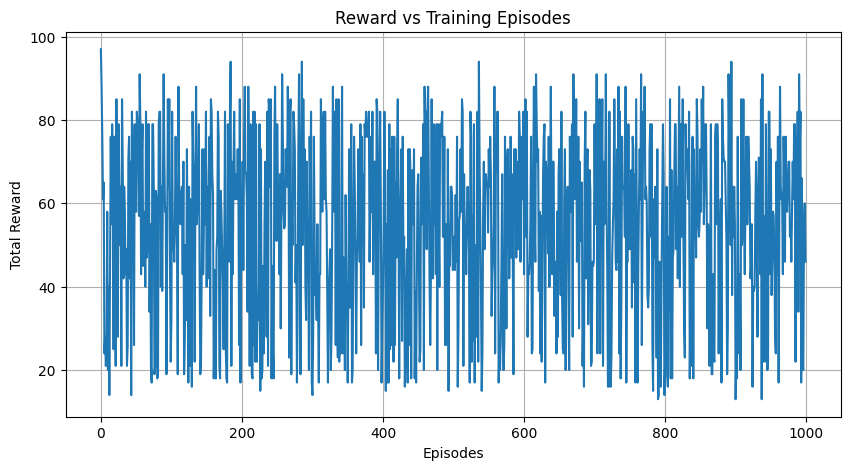

In [112]:
plt.figure(figsize=(10, 5))

plt.plot(rewards_history)

plt.title("Reward vs Training Episodes")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")

plt.grid()
plt.show()

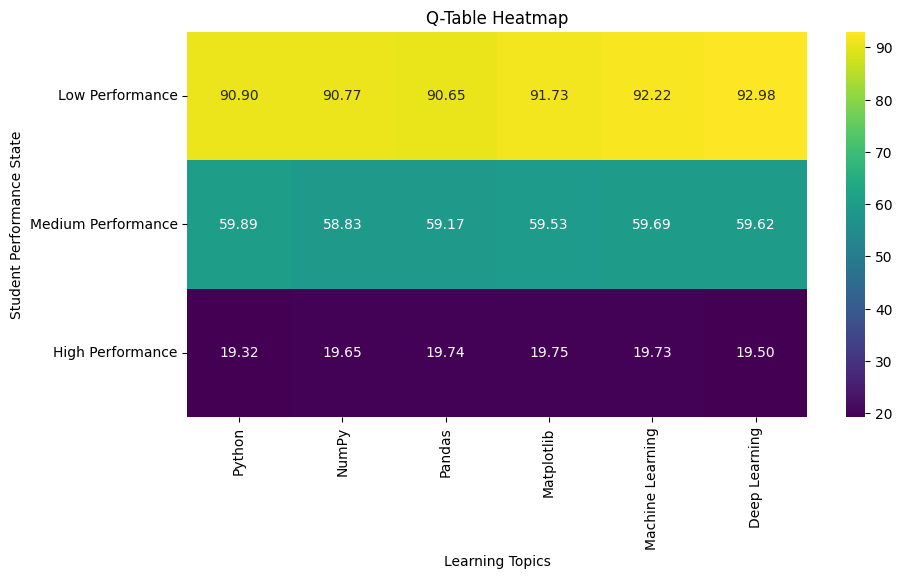

In [113]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    q_table,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Q-Table Heatmap")
plt.xlabel("Learning Topics")
plt.ylabel("Student Performance State")

plt.show()

In [114]:
def recommend_learning_path(student_id):

    student = df[df["Student"] == student_id].iloc[0]

    recommendations = []

    for i, topic in enumerate(topic_columns):

        score = student[topic]

        state = get_state(score)

        q_value = Q[state, i]

        recommendations.append(
            (topics[i], score, q_value)
        )

    recommendation_df = pd.DataFrame(
        recommendations,
        columns=["Topic", "Current Score", "Q-Value"]
    )

    # Sort according to Q-value
    recommendation_df = recommendation_df.sort_values(
        by="Q-Value",
        ascending=False
    )

    return recommendation_df

In [115]:
student_id = "S1"

recommendation = recommend_learning_path(student_id)

print("Recommended Learning Path for", student_id)

display(recommendation)

Recommended Learning Path for S1


,Topic,Current Score,Q-Value
5,Deep Learning,30,92.977927
4,Machine Learning,45,92.222257
3,Matplotlib,55,59.525403
2,Pandas,60,59.172221
1,NumPy,72,58.832845
0,Python,85,19.321789


In [116]:
top_3 = recommendation.head(3)

print("Top 3 Recommended Topics:")

for i, row in top_3.iterrows():
    print(
        row["Topic"],
        "→ Current Score:",
        row["Current Score"]
    )

Top 3 Recommended Topics:
Deep Learning → Current Score: 30
Machine Learning → Current Score: 45
Matplotlib → Current Score: 55


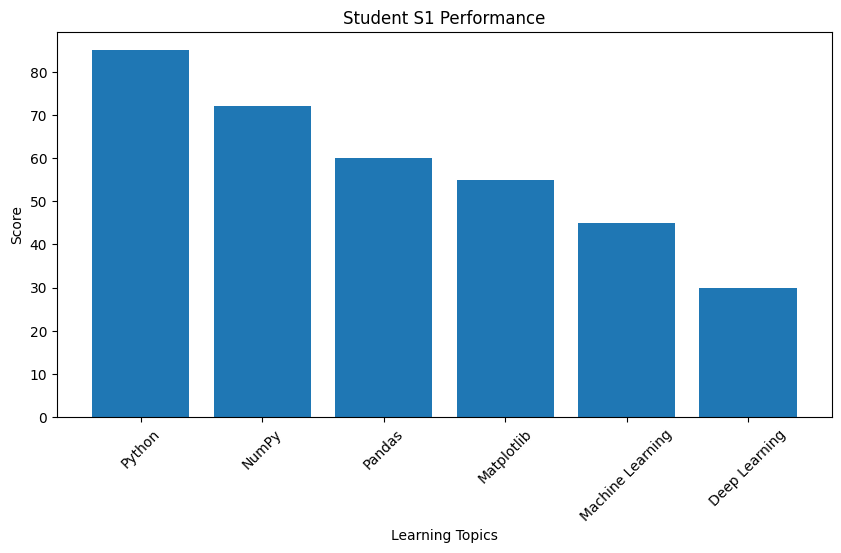

In [117]:
student = df[df["Student"] == "S1"].iloc[0]

scores = student[topic_columns].values

plt.figure(figsize=(10, 5))

plt.bar(topics, scores)

plt.title("Student S1 Performance")
plt.xlabel("Learning Topics")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

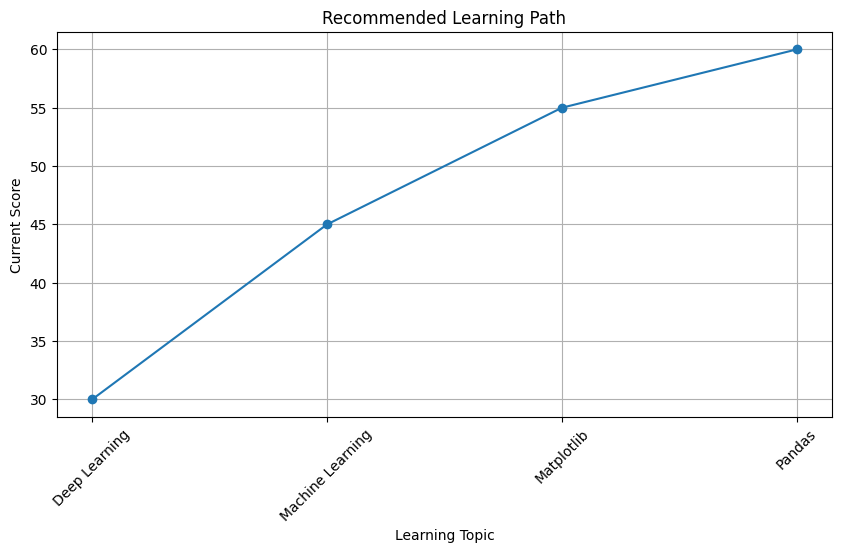

In [118]:
top_topics = recommendation.head(4)

plt.figure(figsize=(10, 5))

plt.plot(
    top_topics["Topic"],
    top_topics["Current Score"],
    marker="o"
)

plt.title("Recommended Learning Path")
plt.xlabel("Learning Topic")
plt.ylabel("Current Score")

plt.xticks(rotation=45)

plt.grid()

plt.show()

In [119]:
all_recommendations = []

for student_id in df["Student"]:

    recommendation = recommend_learning_path(student_id)

    top_topic = recommendation.iloc[0]["Topic"]

    all_recommendations.append(
        [student_id, top_topic]
    )

recommendation_table = pd.DataFrame(
    all_recommendations,
    columns=["Student", "Recommended Topic"]
)

display(recommendation_table)

,Student,Recommended Topic
0,S1,Deep Learning
1,S2,Deep Learning
2,S3,Deep Learning
3,S4,Deep Learning
4,S5,Deep Learning
5,S6,Python
6,S7,Deep Learning
7,S8,Deep Learning
8,S9,Deep Learning
9,S10,Deep Learning


In [120]:
recommendation_count = recommendation_table[
    "Recommended Topic"
].value_counts()

print("Most Recommended Topics:")
display(recommendation_count)

Most Recommended Topics:


,count
Recommended Topic,
Deep Learning,16
Machine Learning,2
Python,1
Matplotlib,1


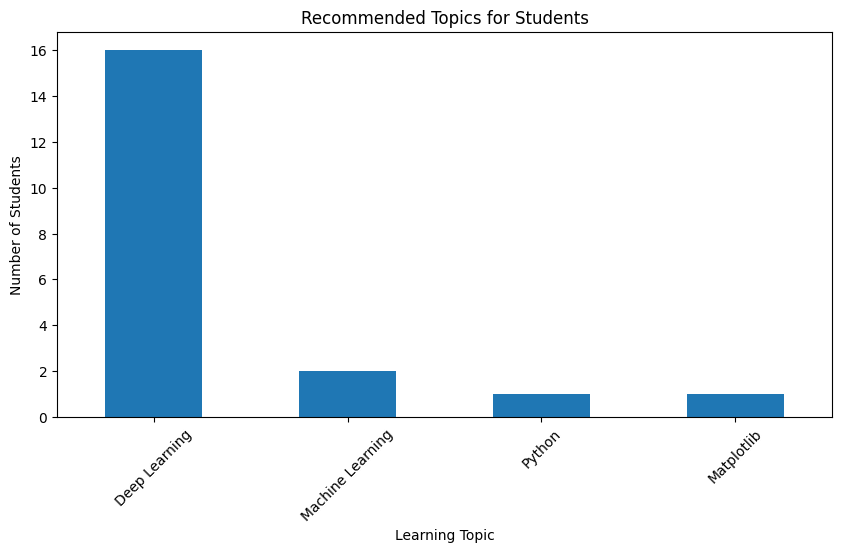

In [121]:
plt.figure(figsize=(10, 5))

recommendation_count.plot(kind="bar")

plt.title("Recommended Topics for Students")
plt.xlabel("Learning Topic")
plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.show()

In [122]:
def get_learning_path(student_id, n=5):

    recommendation = recommend_learning_path(student_id)

    path = recommendation.head(n)

    print("\nPersonalized Learning Path")
    print("----------------------------")
    print("Student:", student_id)

    for position, (_, row) in enumerate(path.iterrows(), start=1):

        print(
            position,
            ".",
            row["Topic"],
            "| Current Score:",
            row["Current Score"]
        )

    return path

In [123]:
learning_path = get_learning_path("S1", 5)


Personalized Learning Path
----------------------------
Student: S1
1 . Deep Learning | Current Score: 30
2 . Machine Learning | Current Score: 45
3 . Matplotlib | Current Score: 55
4 . Pandas | Current Score: 60
5 . NumPy | Current Score: 72


In [124]:
def evaluate_recommendation(student_id):

    student = df[df["Student"] == student_id].iloc[0]

    recommendation = recommend_learning_path(student_id)

    recommended_topic = recommendation.iloc[0]["Topic"]

    column_name = topic_columns[
        topics.index(recommended_topic)
    ]

    score = student[column_name]

    print("Student:", student_id)
    print("Recommended Topic:", recommended_topic)
    print("Current Score:", score)

    if score < 50:
        print("Recommendation Status: Highly Suitable")
    elif score < 75:
        print("Recommendation Status: Suitable")
    else:
        print("Recommendation Status: Revision/Advanced Learning")


In [125]:
evaluate_recommendation("S1")

Student: S1
Recommended Topic: Deep Learning
Current Score: 30
Recommendation Status: Highly Suitable


In [126]:
print("FINAL PERSONALIZED LEARNING RECOMMENDATIONS")
print("=" * 50)

for student_id in df["Student"]:

    recommendation = recommend_learning_path(student_id)

    best_topic = recommendation.iloc[0]["Topic"]

    print(
        student_id,
        "→",
        best_topic
    )

FINAL PERSONALIZED LEARNING RECOMMENDATIONS
S1 → Deep Learning
S2 → Deep Learning
S3 → Deep Learning
S4 → Deep Learning
S5 → Deep Learning
S6 → Python
S7 → Deep Learning
S8 → Deep Learning
S9 → Deep Learning
S10 → Deep Learning
S11 → Deep Learning
S12 → Deep Learning
S13 → Machine Learning
S14 → Deep Learning
S15 → Deep Learning
S16 → Deep Learning
S17 → Matplotlib
S18 → Deep Learning
S19 → Machine Learning
S20 → Deep Learning
